<a href="https://colab.research.google.com/github/Arpmee027/Future_Sales_Prediction_and_EDA/blob/main/Model_Training_Evaluation_and_Selection_for_forecasting_NEW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Loading the dataset

In [ ]:
import pandas as pd

excel_file_path = "/content/drive/MyDrive/Predicting_Future_Sales_Project./Processed_Online_Retail_2.xlsx"
df = pd.read_excel(excel_file_path, sheet_name="Weekly_Shipment_Data")

display(df.head())
display(df.info())

,WeekStartDate,WeeklyShipments,StockCode
0,2010-11-29,986,85123A
1,2010-12-06,1045,85123A
2,2010-12-13,1524,85123A
3,2010-12-20,197,85123A
4,2010-12-27,0,85123A


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211788 entries, 0 to 211787
Data columns (total 3 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   WeekStartDate    211788 non-null  datetime64[ns]
 1   WeeklyShipments  211788 non-null  int64         
 2   StockCode        211788 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 4.8+ MB


None

## Preprocessing the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211788 entries, 0 to 211787
Data columns (total 3 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   WeekStartDate    211788 non-null  datetime64[ns]
 1   WeeklyShipments  211788 non-null  int64         
 2   StockCode        211788 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 4.8+ MB


None


Missing values per column:


,0
WeekStartDate,0
WeeklyShipments,0
StockCode,0



WeeklyShipments descriptive statistics:


,WeeklyShipments
count,211788.000000
mean,26.311311
std,256.773715
min,0.000000
25%,0.000000
50%,0.000000
75%,13.000000
max,80995.000000


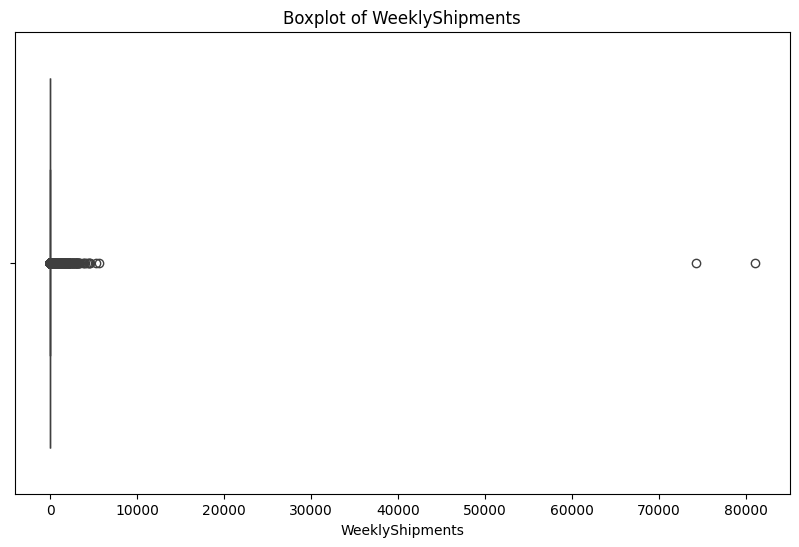

In [ ]:
display(df.info())

# Check for missing values
print("\nMissing values per column:")
display(df.isnull().sum())

# Analyze 'WeeklyShipments' for potential outliers (e.g., using describe and a boxplot)
print("\nWeeklyShipments descriptive statistics:")
display(df['WeeklyShipments'].describe())

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['WeeklyShipments'])
plt.title('Boxplot of WeeklyShipments')
plt.show()

## Splitting the dataset

Splitting the data into training (9 months) and testing (3 months) sets.


In [ ]:
# Determine the start and end dates of the data
start_date = df['WeekStartDate'].min()
end_date = df['WeekStartDate'].max()

# Calculate the split date for 9 months training and 3 months testing
# Add 9 months to the start date to get the approximate split point
split_date = start_date + pd.DateOffset(months=9)

# Filter the DataFrame to create the training and testing sets
train_df = df[df['WeekStartDate'] < split_date].copy()
test_df = df[df['WeekStartDate'] >= split_date].copy()

# Verify the date ranges and the number of records
print("Original DataFrame date range:", start_date, "to", end_date)
print("Training DataFrame date range:", train_df['WeekStartDate'].min(), "to", train_df['WeekStartDate'].max())
print("Testing DataFrame date range:", test_df['WeekStartDate'].min(), "to", test_df['WeekStartDate'].max())

print("\nOriginal DataFrame number of records:", len(df))
print("Training DataFrame number of records:", len(train_df))
print("Testing DataFrame number of records:", len(test_df))

Original DataFrame date range: 2010-11-29 00:00:00 to 2011-12-05 00:00:00
Training DataFrame date range: 2010-11-29 00:00:00 to 2011-08-22 00:00:00
Testing DataFrame date range: 2011-08-29 00:00:00 to 2011-12-05 00:00:00

Original DataFrame number of records: 211788
Training DataFrame number of records: 152958
Testing DataFrame number of records: 58830


## Hyperparameter tuning for SARIMA

A grid of hyperparameters for the SARIMA model (p, d, q) and (P, D, Q, S) is defined for searching, and a time series cross-validation approach is implemented. For each product, the hyperparameter grid is iterated through, and the SARIMA model is evaluated using cross-validation on the training data. The best hyperparameters are selected based on a chosen metric (e.g., AIC, BIC, or a custom cross-validation score). The final SARIMA model for each product is trained using the best hyperparameters on the entire training data. Finally, forecasts for the test set are generated using the tuned SARIMA models.

In [30]:
import itertools
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
import numpy as np

# Define the p, d, q parameters to take any value between 0 and 2
p = d = q = range(0, 1)
# Define the P, D, Q parameters to take any value between 0 and 1
P = D = Q = range(0, 2)
S = 52 # Seasonal period

# Create a grid of all possible parameter combinations
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], S) for x in list(itertools.product(P, D, Q))]

sarima_param_grid = list(itertools.product(pdq, seasonal_pdq))

best_sarima_params = {}
tuned_sarima_forecasts = {}

# Determine the number of weeks in the test set for forecasting
num_test_weeks = test_df['WeekStartDate'].nunique()

In [ ]:
# Ignore convergence warnings for now
warnings.filterwarnings("ignore")

unique_stock_codes = train_df['StockCode'].unique()

best_sarima_params = {} # Dictionary to store best parameters for each stock code

for stock_code in unique_stock_codes:
    product_train_df = train_df[train_df['StockCode'] == stock_code].copy()

    # Calculate the maximum order from the parameter grid
    max_order = max(sarima_param_grid, key=lambda x: sum(x[0]) + sum(x[1][:3])) # Sum p,d,q and P,D,Q
    min_data_required = sum(max_order[0]) + sum(max_order[1][:3]) + 1 # Minimum data points needed is order + 1

    if len(product_train_df) < min_data_required:
         print(f"Skipping SARIMA tuning for {stock_code}: Insufficient data ({len(product_train_df)} records). Minimum required: {min_data_required}")
         best_sarima_params[stock_code] = None
         continue

    # Sort by date and set index
    product_train_df = product_train_df.sort_values(by='WeekStartDate')
    product_train_df.set_index('WeekStartDate', inplace=True)

    best_aic = float('inf')
    best_params = None

    print(f"Tuning SARIMA for {stock_code}")

    for param in sarima_param_grid:
        order = param[0]
        seasonal_order = param[1]

        try:
            model = SARIMAX(product_train_df['WeeklyShipments'],
                            order=order,
                            seasonal_order=seasonal_order,
                            enforce_stationarity=False,
                            enforce_invertibility=False)
            model_fit = model.fit(disp=False)

            if model_fit.aic < best_aic:
                best_aic = model_fit.aic
                best_params = param

        except Exception as e:
            # print(f"Could not fit SARIMA model for {stock_code} with params {param}: {e}")
            continue # Skip to the next parameter combination if fitting fails

    best_sarima_params[stock_code] = best_params
    if best_params is not None:
        print(f"Best parameters for {stock_code}: {best_params}")
    else:
        print(f"No suitable SARIMA parameters found for {stock_code}")


# Display the number of products for which best parameters were found
print(f"\nFound best SARIMA parameters for {len([p for p in best_sarima_params.values() if p is not None])} out of {len(unique_stock_codes)} products.")

## Model training and forecasting (Tuned SARIMA)

Training the final SARIMA model for each product using the best hyperparameters found and generating the forecasts for the test set.

In [ ]:
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Ignore convergence warnings for now
warnings.filterwarnings("ignore")

tuned_sarima_forecasts = {}
num_test_weeks = test_df['WeekStartDate'].nunique()

for stock_code in unique_stock_codes:
    best_params = best_sarima_params.get(stock_code)

    if best_params is None:
        print(f"Skipping final SARIMA training for {stock_code}: No suitable parameters found.")
        tuned_sarima_forecasts[stock_code] = None
        continue

    product_train_df = train_df[train_df['StockCode'] == stock_code].copy()

    # Sort by date and set index
    product_train_df = product_train_df.sort_values(by='WeekStartDate')
    product_train_df.set_index('WeekStartDate', inplace=True)

    print(f"Training final SARIMA model for {stock_code} with parameters {best_params}")

    try:
        final_model = SARIMAX(product_train_df['WeeklyShipments'],
                              order=best_params[0],
                              seasonal_order=best_params[1],
                              enforce_stationarity=False,
                              enforce_invertibility=False)
        final_model_fit = final_model.fit(disp=False)

        # Generate forecast
        forecast = final_model_fit.forecast(steps=num_test_weeks)

        # Store the forecast
        tuned_sarima_forecasts[stock_code] = forecast
        print(f"SARIMA forecast generated for {stock_code} with tuned parameters.")

    except Exception as e:
        print(f"Could not fit final SARIMA model or forecast for {stock_code} with best params {best_params}: {e}")
        tuned_sarima_forecasts[stock_code] = None

# Display the number of products for which tuned SARIMA forecasts were generated
print(f"\nGenerated tuned SARIMA forecasts for {len([f for f in tuned_sarima_forecasts.values() if f is not None])} out of {len(unique_stock_codes)} products.")

## Hyperparameter tuning for XGBoost

A grid of hyperparameters for the XGBoost model (e.g., n_estimators, learning_rate, max_depth) is defined for searching, and a time series cross-validation approach is implemented. For each product, the hyperparameter grid is iterated through, and the XGBoost model is evaluated using cross-validation on the training data. The best hyperparameters are selected based on a chosen metric (e.g., MAE).

In [ ]:
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
import numpy as np
import itertools

# Define a smaller, more manageable parameter grid for tuning
param_grid_xgb = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}

# Create a list of all parameter combinations
keys, values = zip(*param_grid_xgb.items())
param_combinations_xgb = [dict(zip(keys, v)) for v in itertools.product(*values)]

best_xgboost_params = {}

unique_stock_codes = train_df['StockCode'].unique()

# Set up Time Series Cross-Validation
# Use a smaller number of splits for faster tuning
n_splits = 3

for stock_code in unique_stock_codes:
    product_train_df = train_df[train_df['StockCode'] == stock_code].copy()

    if len(product_train_df) < n_splits: # Not enough data for cross-validation
        print(f"Skipping XGBoost tuning for {stock_code}: Insufficient data ({len(product_train_df)} records) for {n_splits} splits.")
        best_xgboost_params[stock_code] = None
        continue

    # Create features for training
    product_train_df = create_features(product_train_df)
    product_train_df = product_train_df.sort_values(by='WeekStartDate')


    X_train_product = product_train_df[['year', 'weekofyear', 'dayofweek']]
    y_train_product = product_train_df['WeeklyShipments']


    best_mae = float('inf')
    best_params = None

    print(f"Tuning XGBoost for {stock_code}")

    for params in param_combinations_xgb:
        tscv = TimeSeriesSplit(n_splits=n_splits)
        fold_mae = []

        for train_index, val_index in tscv.split(X_train_product):
            X_train_fold, X_val_fold = X_train_product.iloc[train_index], X_train_product.iloc[val_index]
            y_train_fold, y_val_fold = y_train_product.iloc[train_index], y_train_product.iloc[val_index]

            try:
                model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, **params)
                model.fit(X_train_fold, y_train_fold)
                predictions = model.predict(X_val_fold)
                mae = mean_absolute_error(y_val_fold, np.maximum(0, np.round(predictions)).astype(int))
                fold_mae.append(mae)
            except Exception as e:
                # print(f"Could not fit XGBoost model for {stock_code} with params {params} on a fold: {e}")
                fold_mae.append(np.inf) # Append infinity if fitting fails


        mean_fold_mae = np.mean(fold_mae)

        if mean_fold_mae < best_mae:
            best_mae = mean_fold_mae
            best_params = params

    best_xgboost_params[stock_code] = best_params
    if best_params is not None:
         print(f"Best parameters for {stock_code}: {best_params} with mean cross-validation MAE: {best_mae}")
    else:
         print(f"No suitable XGBoost parameters found for {stock_code}")

# Display the number of products for which best parameters were found
print(f"\nFound best XGBoost parameters for {len([p for p in best_xgboost_params.values() if p is not None])} out of {len(unique_stock_codes)} products.")

## Model training and forecasting (Tuned XGBoost)

Training the final XGBoost model on the training data for each product using the best hyperparameters found and generating the forecasts for the test set.

In [ ]:
import xgboost as xgb
import numpy as np

tuned_xgboost_forecasts = {}
num_test_weeks = test_df['WeekStartDate'].nunique()

for stock_code in unique_stock_codes:
    best_params = best_xgboost_params.get(stock_code)

    if best_params is None:
        print(f"Skipping final XGBoost training for {stock_code}: No suitable parameters found.")
        tuned_xgboost_forecasts[stock_code] = None
        continue

    product_train_df = train_df[train_df['StockCode'] == stock_code].copy()

    if len(product_train_df) < 2: # Need at least 2 points to create features effectively
        print(f"Skipping final XGBoost training for {stock_code}: Insufficient data ({len(product_train_df)} records).")
        tuned_xgboost_forecasts[stock_code] = None
        continue

    print(f"Training final XGBoost Model for {stock_code} with parameters {best_params}")

    # Create features for training
    product_train_df = create_features(product_train_df)

    # Sort by date after creating features
    product_train_df = product_train_df.sort_values(by='WeekStartDate')

    X_train = product_train_df[['year', 'weekofyear', 'dayofweek']]
    y_train = product_train_df['WeeklyShipments']

    try:
        # Instantiate and train XGBoost model with best parameters
        model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, **best_params)
        model.fit(X_train, y_train)

        # Create future dataframe for forecasting (using dates from the test set)
        future_dates = pd.Series(test_df['WeekStartDate'].unique()).sort_values()
        future_df = pd.DataFrame({'WeekStartDate': future_dates})
        future_df = create_features(future_df)
        X_future = future_df[['year', 'weekofyear', 'dayofweek']]

        # Generate forecasts
        forecast = model.predict(X_future)

        # Ensure forecasts are non-negative integers
        forecast = np.maximum(0, np.round(forecast)).astype(int)

        # Create a pandas Series for the forecast with the correct index
        forecast_series = pd.Series(forecast, index=future_dates, name='WeeklyShipments')

        # Store the forecast
        tuned_xgboost_forecasts[stock_code] = forecast_series
        print(f"XGBoost forecast generated for {stock_code} with tuned parameters.")

    except Exception as e:
        print(f"Could not fit final XGBoost model or forecast for {stock_code} with best params {best_params}: {e}")
        tuned_xgboost_forecasts[stock_code] = None

# Display the number of products for which tuned XGBoost forecasts were successfully generated
print(f"\nGenerated tuned XGBoost forecasts for {len([f for f in tuned_xgboost_forecasts.values() if f is not None])} out of {len(unique_stock_codes)} products.")

## Hyperparameter tuning for LightGBM

A grid of hyperparameters for the LightGBM model (e.g., n_estimators, learning_rate, num_leaves) is defined for searching, and a time series cross-validation approach is implemented. For each product, the hyperparameter grid is iterated through, and the LightGBM model is evaluated using cross-validation on the training data. The best hyperparameters are selected based on a chosen metric (e.g., MAE).

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
import numpy as np
import itertools

# Define a smaller, more manageable parameter grid for tuning
param_grid_lgbm = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1],
    'num_leaves': [31, 62] # Default is 31
}

# Create a list of all parameter combinations
keys, values = zip(*param_grid_lgbm.items())
param_combinations_lgbm = [dict(zip(keys, v)) for v in itertools.product(*values)]


best_lightgbm_params = {}

unique_stock_codes = train_df['StockCode'].unique()

# Set up Time Series Cross-Validation
# Use the same number of splits as for XGBoost for consistency
n_splits = 3

for stock_code in unique_stock_codes:
    product_train_df = train_df[train_df['StockCode'] == stock_code].copy()

    if len(product_train_df) < n_splits: # Not enough data for cross-validation
        print(f"Skipping LightGBM tuning for {stock_code}: Insufficient data ({len(product_train_df)} records) for {n_splits} splits.")
        best_lightgbm_params[stock_code] = None
        continue

    # Create features for training
    product_train_df = create_features(product_train_df)
    product_train_df = product_train_df.sort_values(by='WeekStartDate')


    X_train_product = product_train_df[['year', 'weekofyear', 'dayofweek']]
    y_train_product = product_train_df['WeeklyShipments']


    best_mae = float('inf')
    best_params = None

    print(f"Tuning LightGBM for {stock_code}")

    for params in param_combinations_lgbm:
        tscv = TimeSeriesSplit(n_splits=n_splits)
        fold_mae = []

        for train_index, val_index in tscv.split(X_train_product):
            X_train_fold, X_val_fold = X_train_product.iloc[train_index], X_train_product.iloc[val_index]
            y_train_fold, y_val_fold = y_train_product.iloc[train_index], y_train_product.iloc[val_index]

            try:
                model = lgb.LGBMRegressor(objective='regression_l1', random_state=42, **params)
                model.fit(X_train_fold, y_train_fold)
                predictions = model.predict(X_val_fold)
                mae = mean_absolute_error(y_val_fold, np.maximum(0, np.round(predictions)).astype(int))
                fold_mae.append(mae)
            except Exception as e:
                # print(f"Could not fit LightGBM model for {stock_code} with params {params} on a fold: {e}")
                fold_mae.append(np.inf) # Append infinity if fitting fails


        mean_fold_mae = np.mean(fold_mae)

        if mean_fold_mae < best_mae:
            best_mae = mean_fold_mae
            best_params = params

    best_lightgbm_params[stock_code] = best_params
    if best_params is not None:
         print(f"Best parameters for {stock_code}: {best_params} with mean cross-validation MAE: {best_mae}")
    else:
         print(f"No suitable LightGBM parameters found for {stock_code}")

# Display the number of products for which best parameters were found
print(f"\nFound best LightGBM parameters for {len([p for p in best_lightgbm_params.values() if p is not None])} out of {len(unique_stock_codes)} products.")

## Model training and forecasting (Tuned LightGBM)

Training the final LightGBM model on the training data for each product using the best hyperparameters found and generating the forecasts for the test set.

In [ ]:
import lightgbm as lgb
import numpy as np

tuned_lightgbm_forecasts = {}
num_test_weeks = test_df['WeekStartDate'].nunique()

for stock_code in unique_stock_codes:
    best_params = best_lightgbm_params.get(stock_code)

    if best_params is None:
        print(f"Skipping final LightGBM training for {stock_code}: No suitable parameters found.")
        tuned_lightgbm_forecasts[stock_code] = None
        continue

    product_train_df = train_df[train_df['StockCode'] == stock_code].copy()

    if len(product_train_df) < 2: # Need at least 2 points to create features effectively
        print(f"Skipping final LightGBM training for {stock_code}: Insufficient data ({len(product_train_df)} records).")
        tuned_lightgbm_forecasts[stock_code] = None
        continue

    print(f"Training final LightGBM Model for {stock_code} with parameters {best_params}")

    # Create features for training
    product_train_df = create_features(product_train_df)

    # Sort by date after creating features
    product_train_df = product_train_df.sort_values(by='WeekStartDate')


    X_train = product_train_df[['year', 'weekofyear', 'dayofweek']]
    y_train = product_train_df['WeeklyShipments']

    try:
        # Instantiate and train LightGBM model with best parameters
        model = lgb.LGBMRegressor(objective='regression_l1', random_state=42, **best_params)
        model.fit(X_train, y_train)

        # Create future dataframe for forecasting (using dates from the test set)
        future_dates = pd.Series(test_df['WeekStartDate'].unique()).sort_values()
        future_df = pd.DataFrame({'WeekStartDate': future_dates})
        future_df = create_features(future_df)
        X_future = future_df[['year', 'weekofyear', 'dayofweek']]

        # Generate forecasts
        forecast = model.predict(X_future)

        # Ensure forecasts are non-negative integers
        forecast = np.maximum(0, np.round(forecast)).astype(int)

        # Create a pandas Series for the forecast with the correct index
        forecast_series = pd.Series(forecast, index=future_dates, name='WeeklyShipments')

        # Store the forecast
        tuned_lightgbm_forecasts[stock_code] = forecast_series
        print(f"LightGBM forecast generated for {stock_code} with tuned parameters.")

    except Exception as e:
        print(f"Could not fit final LightGBM model or forecast for {stock_code} with best params {best_params}: {e}")
        tuned_lightgbm_forecasts[stock_code] = None

# Display the number of products for which tuned LightGBM forecasts were successfully generated
print(f"\nGenerated tuned LightGBM forecasts for {len([f for f in tuned_lightgbm_forecasts.values() if f is not None])} out of {len(unique_stock_codes)} products.")

## Model evaluation and comparison (Tuned Models)

The MAE is calculated for each product using the actual values from the test set and the generated forecasts from each tuned model. Then, the average MAE for each tuned model is calculated across all products, and the results are displayed to compare the tuned models.

In [37]:
from sklearn.metrics import mean_absolute_error
import numpy as np

tuned_sarima_maes = {}
tuned_xgboost_maes = {}
tuned_lightgbm_maes = {}

# Ensure the test_df is sorted by date and StockCode for easier lookup
test_df_sorted = test_df.sort_values(by=['StockCode', 'WeekStartDate'])

for stock_code in unique_stock_codes:
    # Get the actual values for the current product in the test set
    actual_values = test_df_sorted[test_df_sorted['StockCode'] == stock_code]['WeeklyShipments']

    # Get the forecasts for the current product from each tuned model
    tuned_sarima_forecast = tuned_sarima_forecasts.get(stock_code)
    tuned_xgboost_forecast = tuned_xgboost_forecasts.get(stock_code)
    tuned_lightgbm_forecast = tuned_lightgbm_forecasts.get(stock_code)

    # Calculate MAE for Tuned SARIMA if forecast exists and matches length of actual values
    if tuned_sarima_forecast is not None and len(tuned_sarima_forecast) == len(actual_values):
        tuned_sarima_maes[stock_code] = mean_absolute_error(actual_values, tuned_sarima_forecast)
    else:
        tuned_sarima_maes[stock_code] = None
        if tuned_sarima_forecast is not None:
             print(f"Tuned SARIMA forecast length mismatch for {stock_code}: Actual={len(actual_values)}, Forecast={len(tuned_sarima_forecast)}")
        else:
             print(f"Tuned SARIMA forecast not available for {stock_code}")


    # Calculate MAE for Tuned XGBoost if forecast exists and matches length of actual values
    if tuned_xgboost_forecast is not None and len(tuned_xgboost_forecast) == len(actual_values):
        tuned_xgboost_maes[stock_code] = mean_absolute_error(actual_values, tuned_xgboost_forecast)
    else:
        tuned_xgboost_maes[stock_code] = None
        if tuned_xgboost_forecast is not None:
             print(f"Tuned XGBoost forecast length mismatch for {stock_code}: Actual={len(actual_values)}, Forecast={len(tuned_xgboost_forecast)}")
        else:
             print(f"Tuned XGBoost forecast not available for {stock_code}")


    # Calculate MAE for Tuned LightGBM if forecast exists and matches length of actual values
    if tuned_lightgbm_forecast is not None and len(tuned_lightgbm_forecast) == len(actual_values):
        tuned_lightgbm_maes[stock_code] = mean_absolute_error(actual_values, tuned_lightgbm_forecast)
    else:
        tuned_lightgbm_maes[stock_code] = None
        if tuned_lightgbm_forecast is not None:
             print(f"Tuned LightGBM forecast length mismatch for {stock_code}: Actual={len(actual_values)}, Forecast={len(tuned_lightgbm_forecast)}")
        else:
             print(f"Tuned LightGBM forecast not available for {stock_code}")


# Calculate the mean MAE across all products for each tuned model, excluding None values
mean_tuned_sarima_mae = np.mean([mae for mae in tuned_sarima_maes.values() if mae is not None])
mean_tuned_xgboost_mae = np.mean([mae for mae in tuned_xgboost_maes.values() if mae is not None])
mean_tuned_lightgbm_mae = np.mean([mae for mae in tuned_lightgbm_maes.values() if mae is not None])


print(f"\nMean MAE across all products for Tuned SARIMA: {mean_tuned_sarima_mae}")
print(f"Mean MAE across all products for Tuned XGBoost: {mean_tuned_xgboost_mae}")
print(f"Mean MAE across all products for Tuned LightGBM: {mean_tuned_lightgbm_mae}")

# Determine the best performing tuned model
best_tuned_model = min({"Tuned SARIMA": mean_tuned_sarima_mae, "Tuned XGBoost": mean_tuned_xgboost_mae, "Tuned LightGBM": mean_tuned_lightgbm_mae}, key=lambda k: eval(f"mean_{k.lower().replace(' ', '_')}_mae"))

print(f"\nBased on the mean MAE, the best performing tuned model is: {best_tuned_model}")


Mean MAE across all products for Tuned SARIMA: 38.49719530851606
Mean MAE across all products for Tuned XGBoost: 30.9667686554479
Mean MAE across all products for Tuned LightGBM: 31.803246642869286

Based on the mean MAE, the best performing tuned model is: Tuned XGBoost


## Visualizing the forecast (Tuned Models)

Visualizing the forecasts from the tuned models against the actual data for a few products.

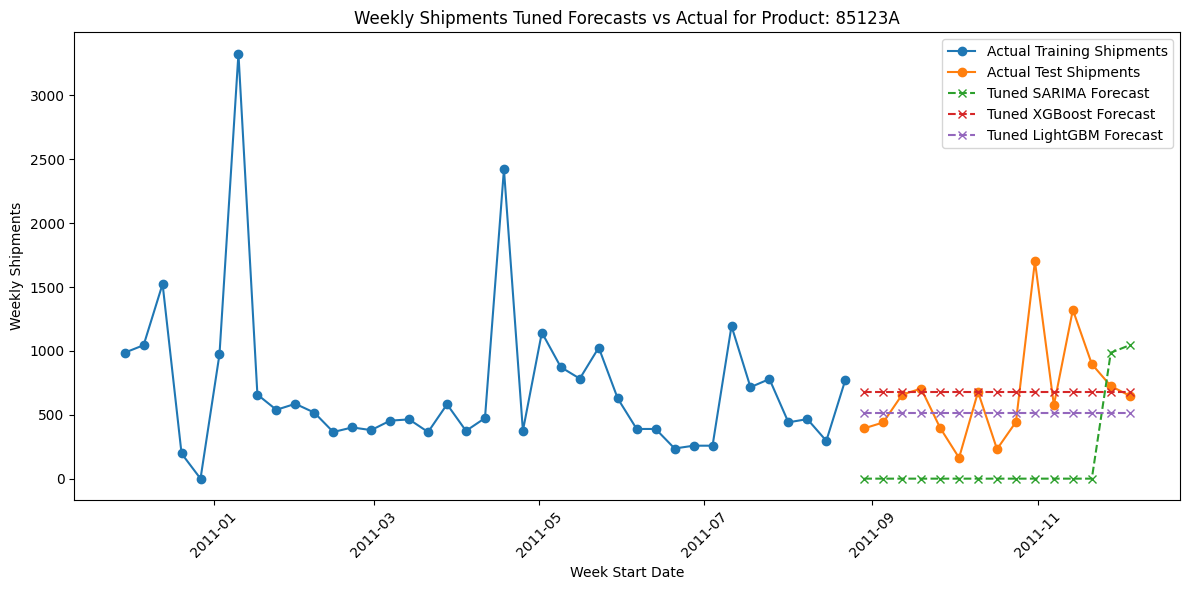

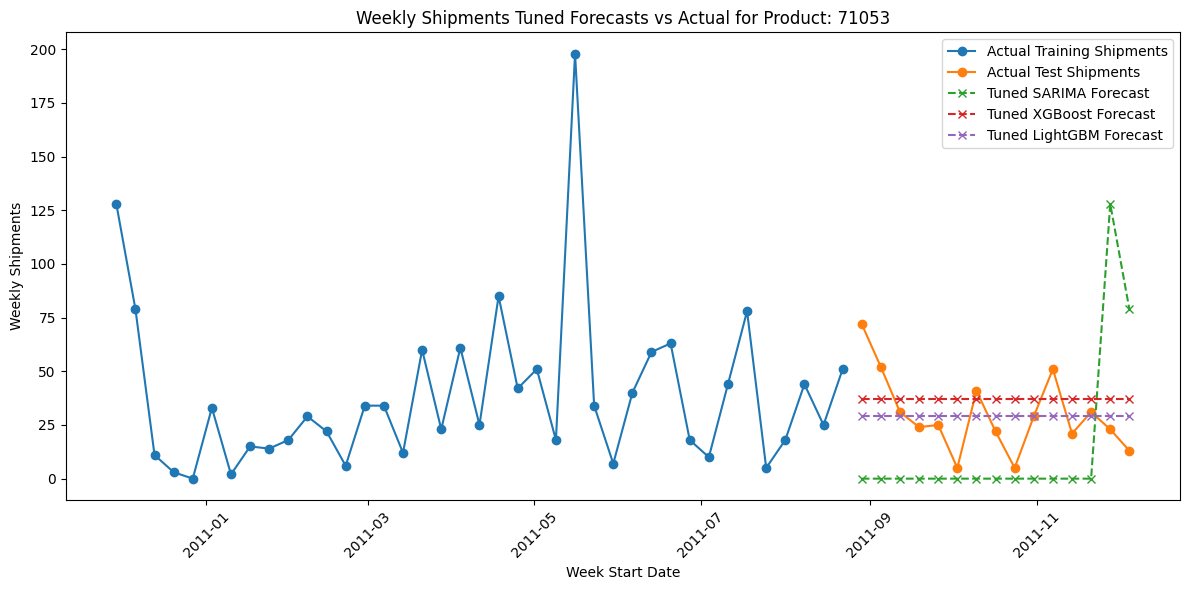

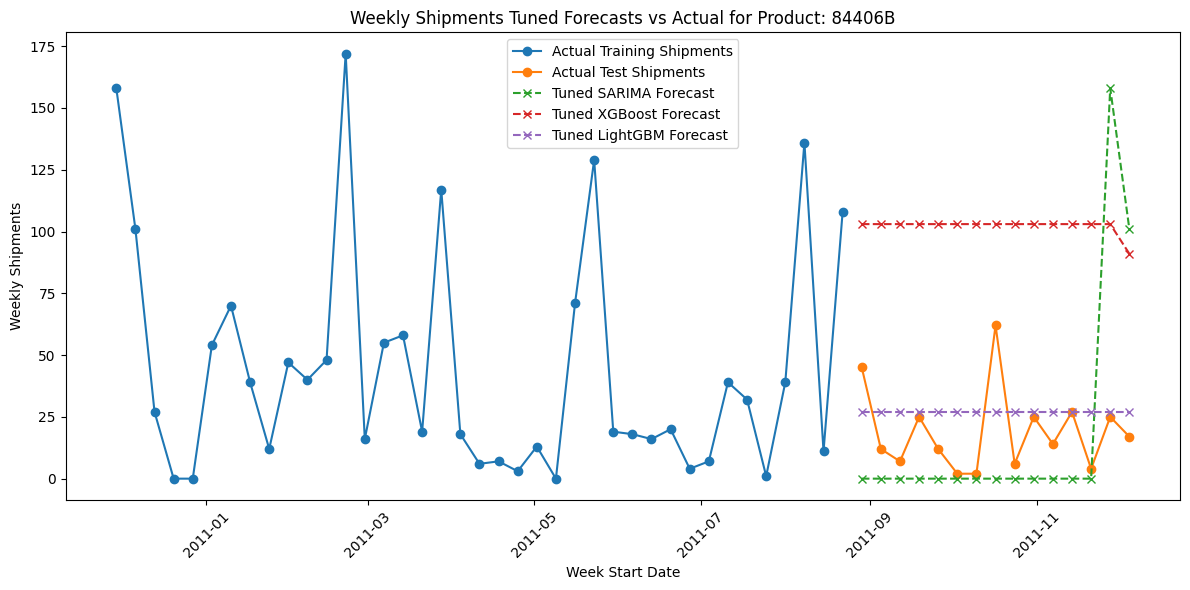

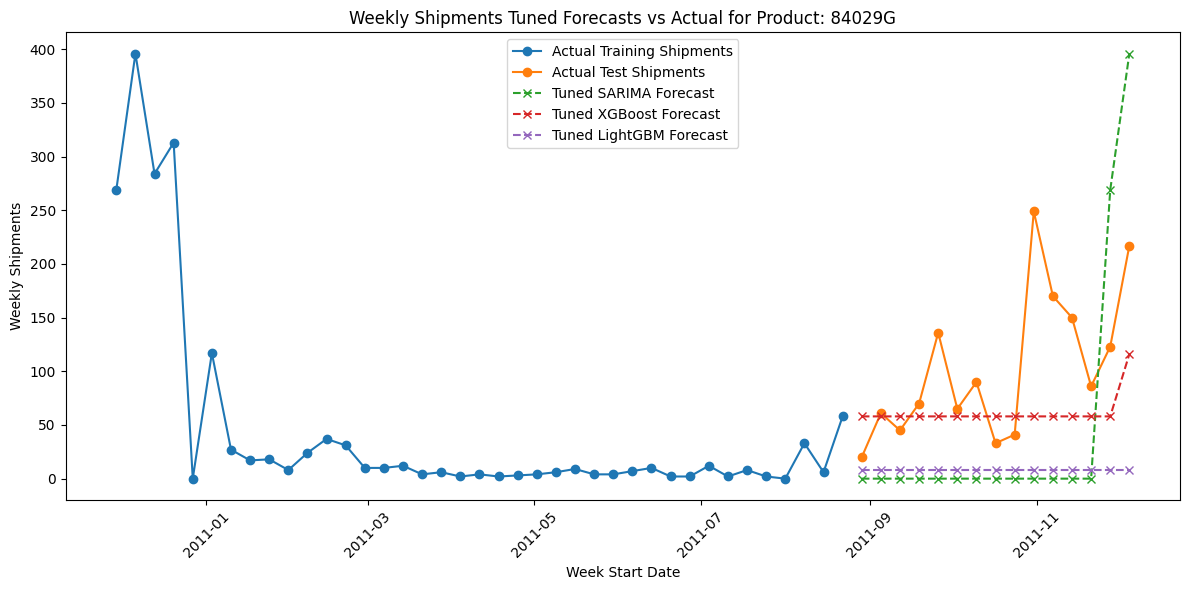

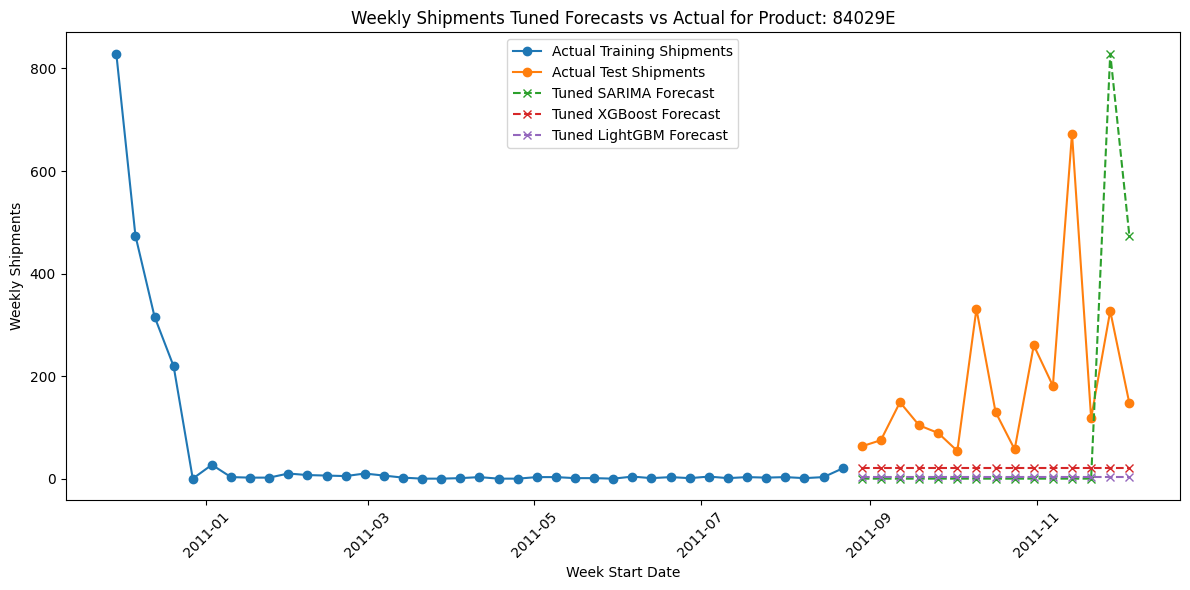

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Select a few sample stock codes for visualization
sample_stock_codes = unique_stock_codes[:5] # Visualize the first 5 products

for stock_code in sample_stock_codes:
    # Get the actual values for the current product in the training and test sets
    product_train_df_viz = train_df[train_df['StockCode'] == stock_code].copy()
    product_test_df_viz = test_df_sorted[test_df_sorted['StockCode'] == stock_code].copy()

    actual_train_values = product_train_df_viz.set_index('WeekStartDate')['WeeklyShipments']
    actual_test_values = product_test_df_viz.set_index('WeekStartDate')['WeeklyShipments']

    # Get the forecasts for the current product from each tuned model
    tuned_sarima_forecast = tuned_sarima_forecasts.get(stock_code)
    tuned_xgboost_forecast = tuned_xgboost_forecasts.get(stock_code)
    tuned_lightgbm_forecast = tuned_lightgbm_forecasts.get(stock_code)


    plt.figure(figsize=(12, 6))
    plt.plot(actual_train_values.index, actual_train_values.values, label='Actual Training Shipments', marker='o', linestyle='-')
    plt.plot(actual_test_values.index, actual_test_values.values, label='Actual Test Shipments', marker='o', linestyle='-')

    if tuned_sarima_forecast is not None and len(tuned_sarima_forecast) == len(actual_test_values):
        tuned_sarima_forecast.index = pd.to_datetime(tuned_sarima_forecast.index)
        plt.plot(tuned_sarima_forecast.index, tuned_sarima_forecast.values, label='Tuned SARIMA Forecast', marker='x', linestyle='--')
    else:
        print(f"Tuned SARIMA forecast not available or length mismatch for {stock_code}")

    if tuned_xgboost_forecast is not None and len(tuned_xgboost_forecast) == len(actual_test_values):
        tuned_xgboost_forecast.index = pd.to_datetime(tuned_xgboost_forecast.index)
        plt.plot(tuned_xgboost_forecast.index, tuned_xgboost_forecast.values, label='Tuned XGBoost Forecast', marker='x', linestyle='--')
    else:
        print(f"Tuned XGBoost forecast not available or length mismatch for {stock_code}")

    if tuned_lightgbm_forecast is not None and len(tuned_lightgbm_forecast) == len(actual_test_values):
        tuned_lightgbm_forecast.index = pd.to_datetime(tuned_lightgbm_forecast.index)
        plt.plot(tuned_lightgbm_forecast.index, tuned_lightgbm_forecast.values, label='Tuned LightGBM Forecast', marker='x', linestyle='--')
    else:
        print(f"Tuned LightGBM forecast not available or length mismatch for {stock_code}")


    plt.title(f'Weekly Shipments Tuned Forecasts vs Actual for Product: {stock_code}')
    plt.xlabel('Week Start Date')
    plt.ylabel('Weekly Shipments')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()